Download Phi-Sat 2 L1 data

In [8]:
from pyrawph import L1_event, InsulaClient
from InsulaWorkflowClient import InsulaOpenIDConnect
from getpass import getpass

insula_auth = InsulaOpenIDConnect(
    authorization_endpoint="https://identity.insula.earth/realms/phisat2/protocol/openid-connect/auth",
    token_endpoint="https://identity.insula.earth/realms/phisat2/protocol/openid-connect/token",
    redirect_uri="http://localhost:9207/auth",
    client_id="api-client",
)

username = input("Insula username/email: ")
password = getpass("Insula password: ")
insula_auth.set_user_credentials(username=username, password=password)

client = InsulaClient(insula_auth=insula_auth)



In [ ]:
# To change event, change the identifier or use the search method instead
evt = L1_event.from_insula_identifier(
    client=client,
    ref_data_collection="phisat24e55ba83dd304ea9b018b65e9b17a7de",
    identifier="phisat_PHISAT-2_L1_000005069_20260415055944_20260415055947_9D7F2888.zip",
)

[PyRawPh] Loading ΦSat-2 L1 from: insula_cache\PHISAT-2_L1_000005069_20260415055944_20260415055947_9D7F2888


In [ ]:
# Search event
evt2 = L1_event.from_insula_search(
    client=client,
    ref_data_collection="phisat24e55ba83dd304ea9b018b65e9b17a7de",
    page=0,
    results_per_page=1,
    feature_index=0,
)

[PyRawPh] Loading ΦSat-2 L1 from: insula_cache\PHISAT-2_L1_000005069_20260415055944_20260415055947_9D7F2888


In [ ]:
data = client.search_ref_data(
    ref_data_collection="phisat24e55ba83dd304ea9b018b65e9b17a7de",
    page=0,
    results_per_page=5,
)

for i, feature in enumerate(data["features"]):
    props = feature["properties"]
    print(i, props["productIdentifier"], props["startDate"])

0 phisat_PHISAT-2_L1_000005069_20260415055944_20260415055947_9D7F2888.zip 2026-04-15T05:59:44Z
1 phisat_PHISAT-2_L1_000005068_20260415042548_20260415042551_9722AB0D.zip 2026-04-15T04:25:48Z
2 phisat_PHISAT-2_L1_000005067_20260415025130_20260415025133_698EEDE3.zip 2026-04-15T02:51:30Z
3 phisat_PHISAT-2_L1_000005066_20260415012624_20260415012627_E405230D.zip 2026-04-15T01:26:24Z
4 phisat_PHISAT-2_L1_000005065_20260414185628_20260414185631_416D30D1.zip 2026-04-14T18:56:28Z


Open and process L0/L1 data

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from pyrawph import (
    L0_event,
    L1_event,
    register_l0_to_l1_space,
    project_bbox_l1_to_l0_native,
)

In [14]:
def show_img(img, title="", cmap="gray", figsize=(6, 6)):
    x = img.astype(np.float32)
    x = x - x.min()
    if x.max() > 0:
        x = x / x.max()

    plt.figure(figsize=figsize)
    plt.imshow(x, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def overlay(red_img, green_img, title="overlay", figsize=(6, 6)):
    r = red_img.astype(np.float32)
    g = green_img.astype(np.float32)

    r = r - r.min()
    g = g - g.min()

    if r.max() > 0:
        r = r / r.max()
    if g.max() > 0:
        g = g / g.max()

    rgb = np.zeros((r.shape[0], r.shape[1], 3), dtype=np.float32)
    rgb[..., 0] = r
    rgb[..., 1] = g

    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_bbox(img, bbox, title="bbox", figsize=(6, 6)):
    y0, x0, y1, x1 = [int(round(v)) for v in bbox]

    x = img.astype(np.float32)
    x = x - x.min()
    if x.max() > 0:
        x = x / x.max()

    plt.figure(figsize=figsize)
    plt.imshow(x, cmap="gray")
    plt.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], linewidth=2)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_bbox_zoom(img, bbox, margin=100, title="bbox zoom", figsize=(6, 6)):
    y0, x0, y1, x1 = [int(round(v)) for v in bbox]
    H, W = img.shape

    yy0 = max(0, y0 - margin)
    xx0 = max(0, x0 - margin)
    yy1 = min(H, y1 + margin)
    xx1 = min(W, x1 + margin)

    crop = img[yy0:yy1, xx0:xx1].astype(np.float32)
    crop = crop - crop.min()
    if crop.max() > 0:
        crop = crop / crop.max()

    cx0, cy0 = x0 - xx0, y0 - yy0
    cx1, cy1 = x1 - xx0, y1 - yy0

    plt.figure(figsize=figsize)
    plt.imshow(crop, cmap="gray")
    plt.plot([cx0, cx1, cx1, cx0, cx0], [cy0, cy0, cy1, cy1, cy0], linewidth=2)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [4]:
DATA = Path("data")

l0_path = DATA / "L0" / "PHISAT-2_L0_000004513_20260126174009_20260126174011_03EAF334"
l1_path = DATA / "L1" / "PHISAT-2_L1_000004513_20260126174009_20260126174011_03EAF334"

print("L0:", l0_path)
print("L1:", l1_path)

L0: data\L0\PHISAT-2_L0_000004513_20260126174009_20260126174011_03EAF334
L1: data\L1\PHISAT-2_L1_000004513_20260126174009_20260126174011_03EAF334


In [5]:
l0 = L0_event.from_path(str(l0_path), scene_id=0)
l1 = L1_event.from_path(str(l1_path))

print("L0 shape:", l0.as_numpy().shape)
print("L1 shape:", l1.as_numpy().shape)

[PyRawPh] Loading ΦSat-2 L1 from: data\L1\PHISAT-2_L1_000004513_20260126174009_20260126174011_03EAF334
L0 shape: (8, 4096, 4096)
L1 shape: (8, 4096, 4096)


In [6]:
l0.show_event_info()
print()
l1.show_event_info()

=== L0_event ===
Product folder      : data\L0\PHISAT-2_L0_000004513_20260126174009_20260126174011_03EAF334
Scene ID            : 0
Array shape         : (8, 4096, 4096)
Dtype               : uint16
Band indices        : [0, 1, 2, 3, 4, 5, 6, 7]
Band wavelengths nm : [625, 490, 560, 665, 705, 740, 783, 842]
Band start rows     : [1552, 2148, 1936, 1756, 1136, 912, 696, 1344]
Line period         : 646
Native space        : L0_native
Metadata path       : data\L0\PHISAT-2_L0_000004513_20260126174009_20260126174011_03EAF334\metadata.json
Ancillary path      : data\L0\PHISAT-2_L0_000004513_20260126174009_20260126174011_03EAF334\ancillary.json

Event: scene_id=0 kind=BC
  folder: data\L1\PHISAT-2_L1_000004513_20260126174009_20260126174011_03EAF334
  path: data\L1\PHISAT-2_L1_000004513_20260126174009_20260126174011_03EAF334\bands\scene_0_BC_multiband.tiff
  shape: (8, 4096, 4096)   dtype: float32
  crs: EPSG:4326
  bounds: None
  wavelengths_nm: [625, 490, 560, 665, 705, 740, 783, 842]
  gl_

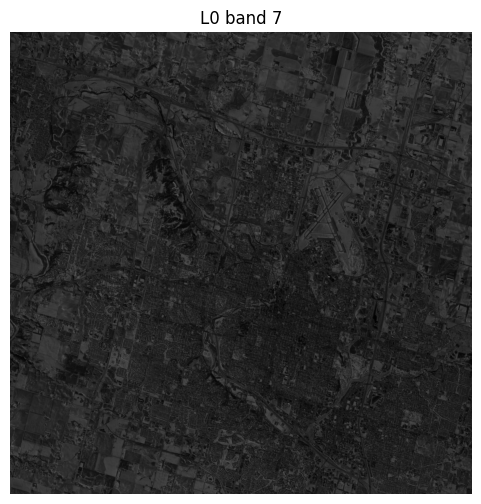

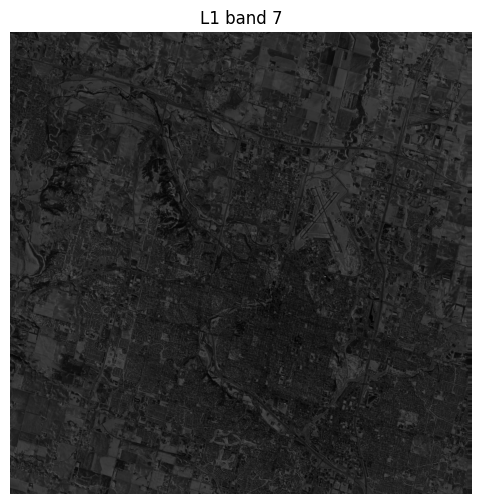

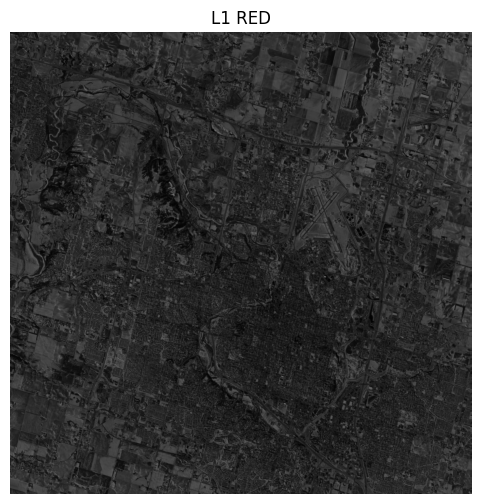

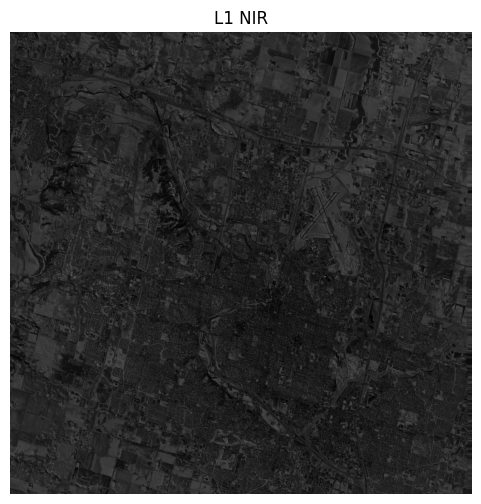

In [7]:
# direct access by band index
l0_b7 = l0.get_band(7)
l1_b7 = l1.get_band(7)

# access by alias / wavelengths
l1_red = l1.get_band("RED")
l1_nir = l1.get_band("NIR")
l0_nir = l0.get_band("NIR")

show_img(l0_b7, title="L0 band 7")
show_img(l1_b7, title="L1 band 7")
show_img(l1_red, title="L1 RED")
show_img(l1_nir, title="L1 NIR")

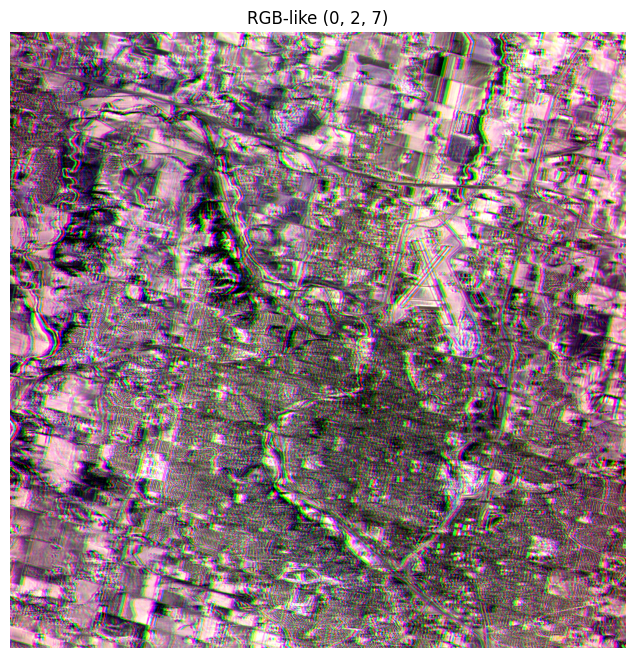

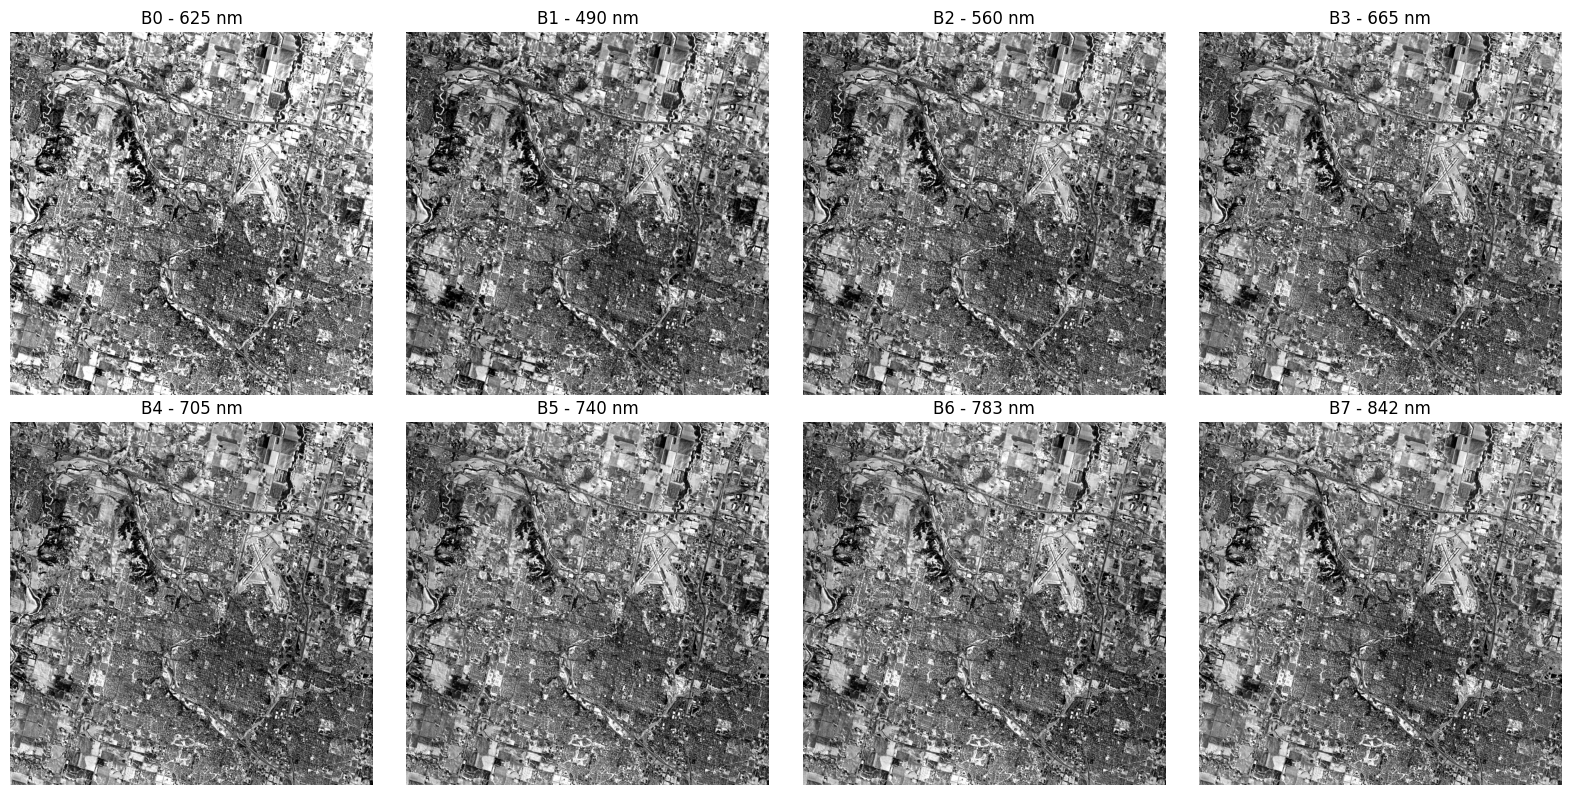

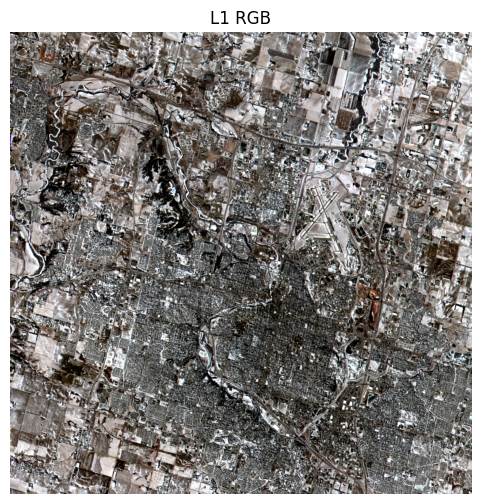

In [8]:
# L0 side : integrated plotting helpers
l0.plot_rgb()
l0.plot_all_bands()

# L1 side : RGB via the rgb() method
l1_rgb = l1.rgb()
show_img(l1_rgb, title="L1 RGB", cmap=None)

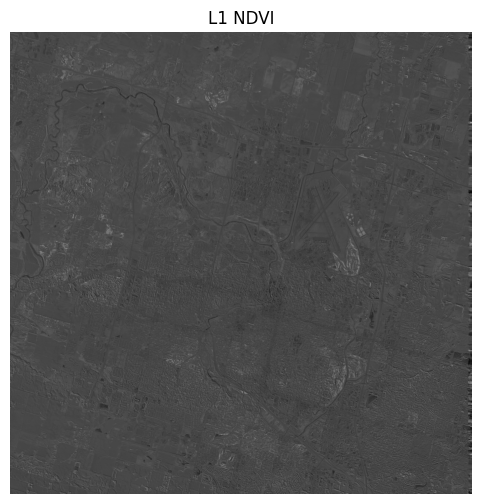

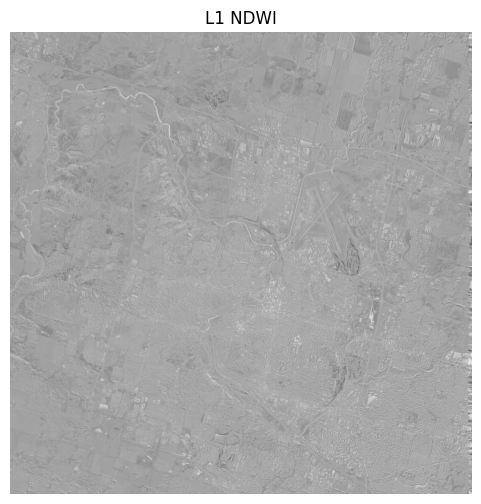

In [9]:
ndvi = l1.index("NDVI")
ndwi = l1.index("NDWI")

show_img(ndvi, title="L1 NDVI")
show_img(ndwi, title="L1 NDWI")

L0 crop shape: (8, 700, 800)
L1 crop shape: (8, 700, 800)


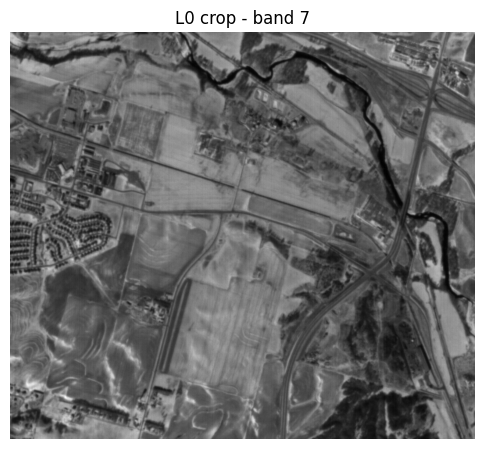

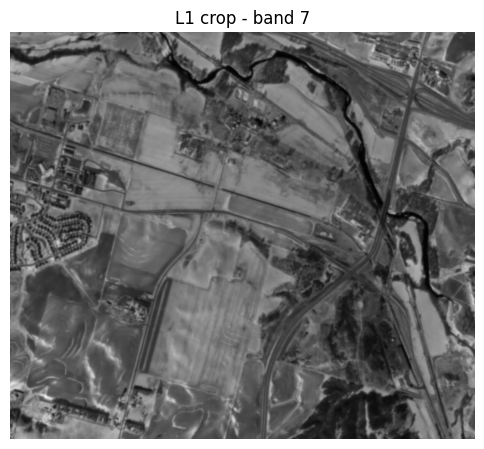

In [10]:
# arbitrary crop to show crop_px
y0, y1, x0, x1 = 500, 1200, 700, 1500

l0_crop = l0.crop_px(y0, y1, x0, x1)
l1_crop = l1.crop_px(y0, y1, x0, x1)

print("L0 crop shape:", l0_crop.as_numpy().shape)
print("L1 crop shape:", l1_crop.as_numpy().shape)

show_img(l0_crop.get_band(7), title="L0 crop - band 7")
show_img(l1_crop.get_band(7), title="L1 crop - band 7")

In [11]:
l0_reg = register_l0_to_l1_space(
    l0_event=l0,
    l1_event=l1,
    master_band=7,
    max_shifts=(300, 300),
)

print("L0 registered shape:", l0_reg.as_numpy().shape)

reg_info = l0_reg.get_meta()["registration_info"]
for k, v in reg_info.items():
    print(f"{k}: {v}")

L0 registered shape: (8, 4096, 4096)
method: phase_correlation_master_then_bands
master_band: 7
reference_space: L1_band_7
master_shift_l0_to_l1_dy_dx: [-1.0, -34.0]
band_shifts_to_ref_dy_dx: {'0': [0.0, -22.0], '1': [0.0, 14.0], '2': [0.0, 1.0], '3': [-1.0, -11.0], '4': [0.0, -45.0], '5': [-1.0, -58.0], '6': [-1.0, -70.0], '7': [0.0, 0.0]}
source_l1_path: data\L1\PHISAT-2_L1_000004513_20260126174009_20260126174011_03EAF334\bands\scene_0_BC_multiband.tiff
l0_original_shape: [8, 4096, 4096]
l0_registered_shape: [8, 4096, 4096]
l1_shape: [8, 4096, 4096]
l0_pre_crop_strategy: none
l0_top_crop_removed_rows: 0


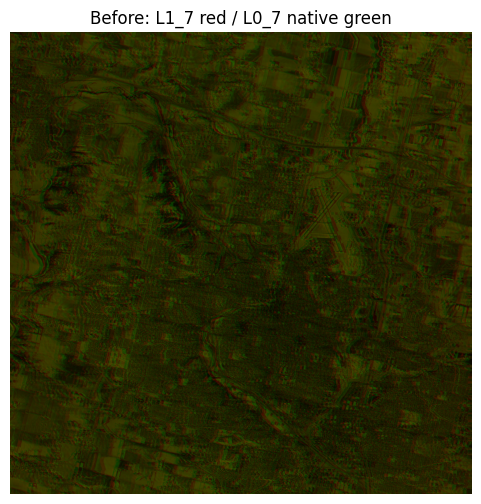

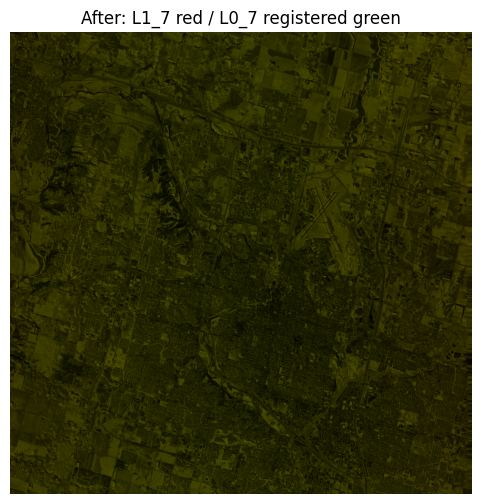

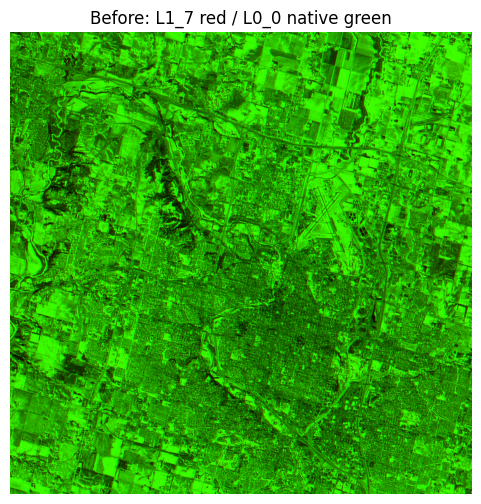

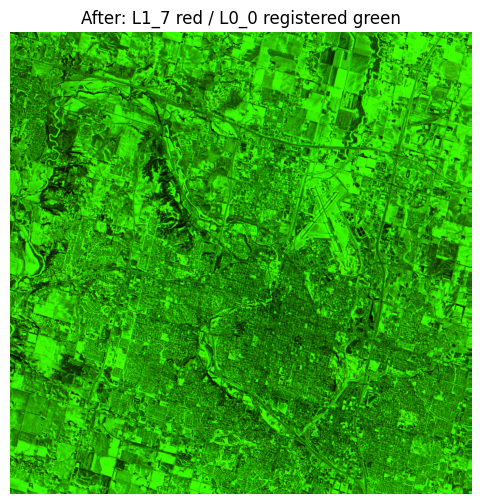

In [12]:
ref = l1.get_band(7)

# master band
overlay(ref, l0.get_band(7), title="Before: L1_7 red / L0_7 native green")
overlay(ref, l0_reg.get_band(7), title="After: L1_7 red / L0_7 registered green")

# another band
overlay(ref, l0.get_band(0), title="Before: L1_7 red / L0_0 native green")
overlay(ref, l0_reg.get_band(0), title="After: L1_7 red / L0_0 registered green")

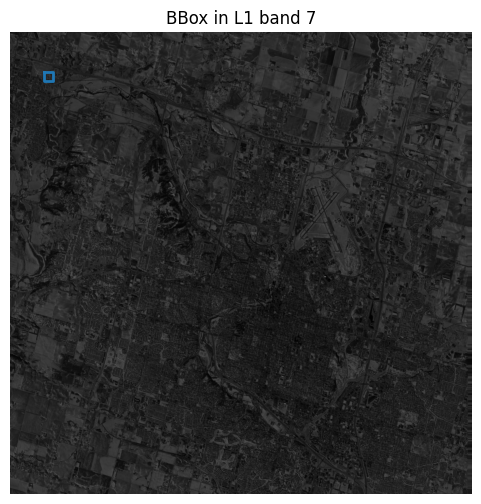

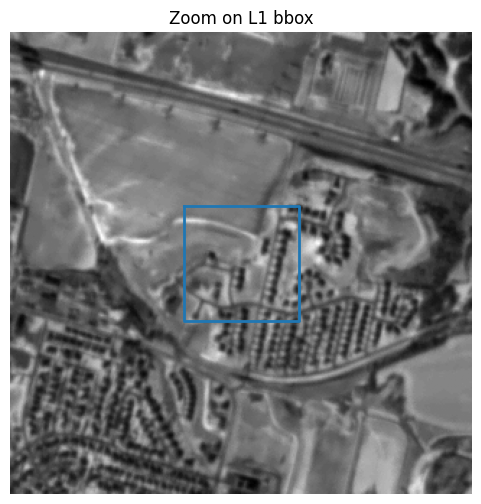

In [13]:
bbox_l1 = [350, 300, 430, 380]   # [y0, x0, y1, x1]

show_bbox(l1.get_band(7), bbox_l1, title="BBox in L1 band 7")
show_bbox_zoom(l1.get_band(7), bbox_l1, margin=120, title="Zoom on L1 bbox")

In [14]:
bbox_l0_band7 = project_bbox_l1_to_l0_native(
    bbox_yxyx=bbox_l1,
    registration_info=reg_info,
    target_band=7,
)

bbox_l0_band0 = project_bbox_l1_to_l0_native(
    bbox_yxyx=bbox_l1,
    registration_info=reg_info,
    target_band=0,
)

print("bbox_l1      :", bbox_l1)
print("bbox_l0_b7   :", bbox_l0_band7)
print("bbox_l0_b0   :", bbox_l0_band0)

bbox_l1      : [350, 300, 430, 380]
bbox_l0_b7   : [351.0, 334.0, 431.0, 414.0]
bbox_l0_b0   : [350.0, 322.0, 430.0, 402.0]


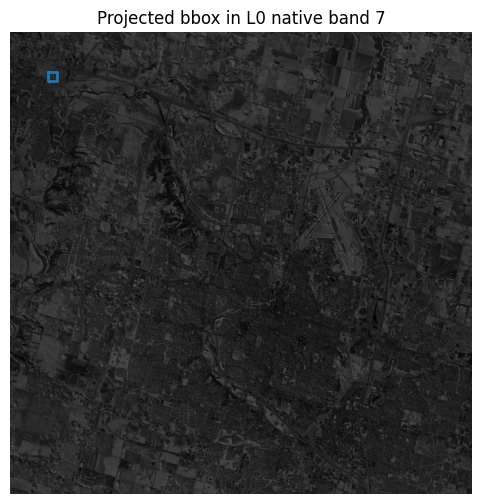

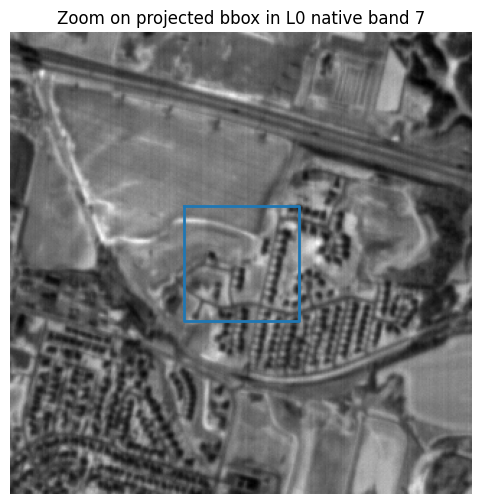

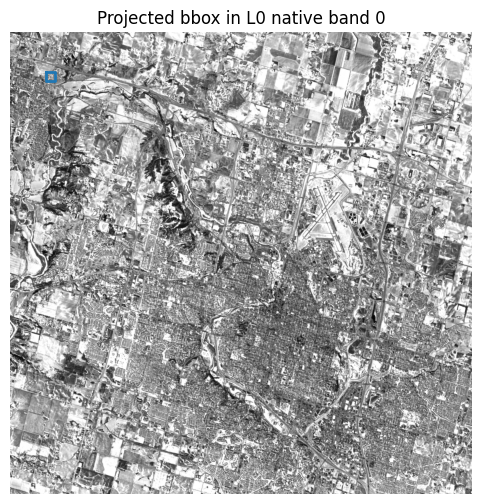

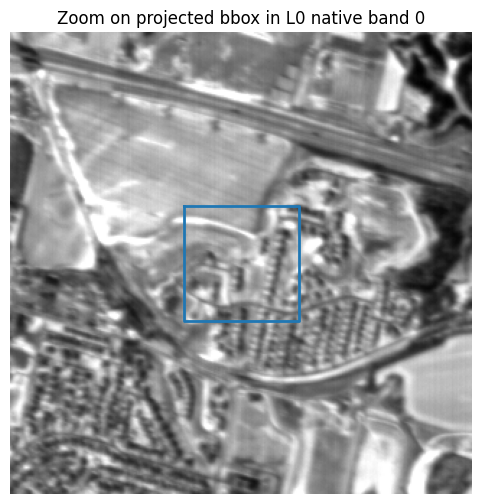

In [15]:
show_bbox(l0.get_band(7), bbox_l0_band7, title="Projected bbox in L0 native band 7")
show_bbox_zoom(l0.get_band(7), bbox_l0_band7, margin=120, title="Zoom on projected bbox in L0 native band 7")

show_bbox(l0.get_band(0), bbox_l0_band0, title="Projected bbox in L0 native band 0")
show_bbox_zoom(l0.get_band(0), bbox_l0_band0, margin=120, title="Zoom on projected bbox in L0 native band 0")

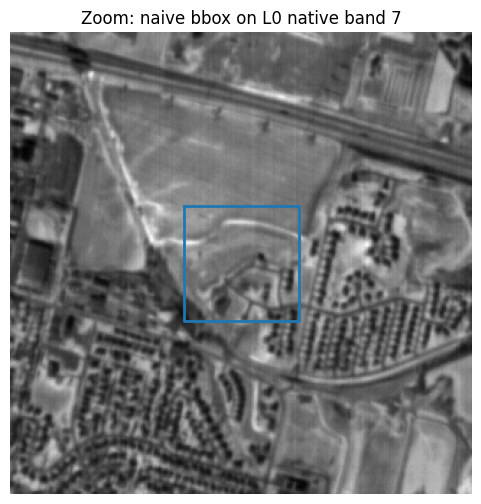

In [16]:
show_bbox_zoom(
    l0.get_band(7),
    bbox_l1,
    margin=120,
    title="Zoom: naive bbox on L0 native band 7"
)

In [17]:
out_dir = Path("demo_outputs")
out_dir.mkdir(exist_ok=True)

# export of georeferenced L1 crop
l1_crop.export_to_tif(str(out_dir / "demo_l1_crop.tif"))

# export of L0 already registered in the L1 space
l0_reg.export_to_tif(str(out_dir / "demo_l0_in_l1_space.tif"))

# export of a cropped raw L0
l0_crop.export_to_tif(str(out_dir / "demo_l0_crop.tif"))

print("Files written to:", out_dir.resolve())

Files written to: C:\Users\Malo.DePastor\PyRawPh - Copy\demo_outputs


In [21]:
from rasterio.transform import array_bounds, xy

meta = l1.get_meta()

crs = meta["crs"]
transform_aff = meta["transform"]
width = meta["width"]
height = meta["height"]

print("CRS      :", crs)
print("Width    :", width)
print("Height   :", height)
print("Transform:", transform_aff)

west, south, east, north = array_bounds(height, width, transform_aff)

print("\nReconstructed bounds:")
print(f"west  = {west}")
print(f"east  = {east}")
print(f"south = {south}")
print(f"north = {north}")

corners = {
    "top_left": (0, 0),
    "top_right": (0, width - 1),
    "bottom_left": (height - 1, 0),
    "bottom_right": (height - 1, width - 1),
    "center": (height // 2, width // 2),
}

print("\nCoordinates (lat, lon):")
for name, (row, col) in corners.items():
    lon, lat = xy(transform_aff, row, col, offset="center")
    print(f"{name:12s}: lat={lat:.6f}, lon={lon:.6f}")

CRS      : EPSG:4326
Width    : 4096
Height   : 4096
Transform: |-0.00,-0.00,-96.55|
| 0.00,-0.00, 43.73|
| 0.00, 0.00, 1.00|

Reconstructed bounds:
west  = -96.8356186571591
east  = -96.55272630840787
south = 43.56211564744168
north = 43.76749833044427

Coordinates (lat, lon):
top_left    : lat=43.728179, lon=-96.552761
top_right   : lat=43.767473, lon=-96.781579
bottom_left : lat=43.562141, lon=-96.606766
bottom_right: lat=43.601435, lon=-96.835584
center      : lat=43.664792, lon=-96.694207


In [22]:
from rasterio.transform import xy

t = l1.get_meta()["transform"]
H = l1.get_meta()["height"]
W = l1.get_meta()["width"]

row = H // 2
col = W // 2
step = 200

lon_c, lat_c = xy(t, row, col, offset="center")
lon_r, lat_r = xy(t, row, col + step, offset="center")
lon_d, lat_d = xy(t, row + step, col, offset="center")

print("Center:")
print(f"  lat={lat_c:.6f}, lon={lon_c:.6f}")

print("\nWhen moving RIGHT in the image:")
print(f"  dlat = {lat_r - lat_c:.6f}")
print(f"  dlon = {lon_r - lon_c:.6f}")

print("\nWhen moving DOWN in the image:")
print(f"  dlat = {lat_d - lat_c:.6f}")
print(f"  dlon = {lon_d - lon_c:.6f}")

Center:
  lat=43.664792, lon=-96.694207

When moving RIGHT in the image:
  dlat = 0.001919
  dlon = -0.011175

When moving DOWN in the image:
  dlat = -0.008109
  dlon = -0.002638


In [23]:
from rasterio.transform import xy

meta = l1.get_meta()
t = meta["transform"]
H = meta["height"]
W = meta["width"]

pts = {
    "top_left": (0, 0),
    "top_right": (0, W - 1),
    "bottom_left": (H - 1, 0),
    "bottom_right": (H - 1, W - 1),
}

for name, (row, col) in pts.items():
    lon, lat = xy(t, row, col, offset="center")
    print(f"{name:12s}: lat={lat:.6f}, lon={lon:.6f}")

top_left    : lat=43.728179, lon=-96.552761
top_right   : lat=43.767473, lon=-96.781579
bottom_left : lat=43.562141, lon=-96.606766
bottom_right: lat=43.601435, lon=-96.835584


In [1]:
path = r"C:\Users\Malo.DePastor\PyRawPh - Light - Copy\data\L2\PHISAT-2_CLOUD_000004451_20260119130559_20260119130602_AAC4DEBC\metadata.json"

with open(path, "r", encoding="utf-8") as f:
    content = f.read()

print(content[-200:])

 {"ExposureTimestamp": 63212136}, "508": {"ExposureTimestamp": 63217440}, "509": {"ExposureTimestamp": 63222744}, "510": {"ExposureTimestamp": 63228048}, "511": {"ExposureTimestamp": 63233352}}}}}}}}}


In [2]:
#!/usr/bin/env python3


import logging
import shutil
import subprocess
import sys
import time
from pathlib import Path

# -----------------------
# PATHS fissi
# -----------------------
L0_ROOT = Path("C:\\Users\\Malo.DePastor\\PyRawPh - Light - Copy\\data\\L0")
SIM_ROOT = Path("C:\\Users\\Malo.DePastor\\PyRawPh\\simtotiff\\simtotiff\\SA072-SENSE-Conversion-Code-main\\SA072-SENSE-Conversion-Code-main")
SIMERA_DIR = SIM_ROOT / "simera"  
PACKET_SCRIPT = "packet_to_tiff.py"  
PYTHON_EXE = "python" 

# breve intervallo I/O tra iterazioni
SLEEP_BETWEEN = 0.2

# -----------------------
# Logging
# -----------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)

def safe_rmtree(p: Path):
    """Rimuove una cartella ricorsivamente se esiste, logga eventuali errori ma non solleva."""
    try:
        if p.exists():
            logging.info("Rimuovo cartella esistente: %s", p)
            shutil.rmtree(p)
    except Exception as e:
        logging.warning("Errore rimuovendo %s: %s", p, e)

def safe_unlink(f: Path):
    """Rimuove un file se esiste, logga eventuali errori ma non solleva."""
    try:
        if f.exists():
            logging.info("Rimuovo file esistente: %s", f)
            f.unlink()
    except Exception as e:
        logging.warning("Errore rimuovendo file %s: %s", f, e)

def run_packet_to_tiff_blocking(simera_dir: Path):
    """
    Esegue packet_to_tiff.py nella cartella simera_dir SENZA timeout.
    L'output del processo viene mostrato in tempo reale.
    Blocca finché il processo non termina. Restituisce il codice di uscita (int).
    """
    cmd = [PYTHON_EXE, PACKET_SCRIPT]
    logging.info("Eseguo (bloccante): %s in %s", " ".join(cmd), simera_dir)
    try:
        completed = subprocess.run(cmd, cwd=str(simera_dir), check=False)
        logging.info("%s terminato con returncode=%s", PACKET_SCRIPT, completed.returncode)
        return completed.returncode
    except Exception:
        logging.exception("Errore eseguendo %s", PACKET_SCRIPT)
        return 1

def copy_tree_replace(src: Path, dst: Path):
    """Copia src in dst; se dst esiste lo rimuove prima (sovrascrive tutto)."""
    if dst.exists():
        logging.info("Rimuovo esistente %s", dst)
        shutil.rmtree(dst)
    logging.info("Copio %s -> %s", src, dst)
    # shutil.copytree con dirs_exist_ok disponibile su Python>=3.8
    try:
        shutil.copytree(src, dst, dirs_exist_ok=True)
    except TypeError:
        shutil.copytree(src, dst)

def main():
    # sanity checks
    if not L0_ROOT.is_dir():
        logging.error("L0 root non trovato: %s", L0_ROOT)
        sys.exit(1)
    if not SIM_ROOT.is_dir():
        logging.error("SIM_ROOT non trovato: %s", SIM_ROOT)
        sys.exit(1)
    if not SIMERA_DIR.is_dir():
        logging.error("SIMERA_DIR non trovato: %s", SIMERA_DIR)
        sys.exit(1)
    if not (SIMERA_DIR / PACKET_SCRIPT).exists():
        logging.error("Script %s non trovato in %s", PACKET_SCRIPT, SIMERA_DIR)
        sys.exit(1)

    sim_root_raw_folder = SIM_ROOT / "raw"
    sim_root_raw_bin = SIM_ROOT / "raw.bin"

    subdirs = sorted([p for p in L0_ROOT.iterdir() if p.is_dir()])
    logging.info("Trovate %d sottocartelle in %s", len(subdirs), L0_ROOT)

    for i, sub in enumerate(subdirs, start=1):
        logging.info("(%d/%d) Processing %s", i, len(subdirs), sub)
        raw_bin = sub / "raw.bin"
        if not raw_bin.exists():
            logging.info("  -> raw.bin non presente in %s, salto.", sub)
            continue

        # 0) PULIZIA PREVENTIVA in SIM_ROOT
        safe_rmtree(sim_root_raw_folder)
        safe_unlink(sim_root_raw_bin)

        # 1) copia raw.bin in SIM_ROOT (parent della simera)
        try:
            logging.info("  -> Copio %s -> %s", raw_bin, sim_root_raw_bin)
            shutil.copy2(raw_bin, sim_root_raw_bin)
        except Exception as e:
            logging.error("  -> Errore copiando raw.bin: %s", e)
            # assicurati di non lasciare raw.bin parziale
            safe_unlink(sim_root_raw_bin)
            continue

        # 2) esegui packet_to_tiff.py dentro SIMERA_DIR e aspetta la fine
        rc = run_packet_to_tiff_blocking(SIMERA_DIR)

        # 3) se esito != 0 -> logga e pulizia, continua
        if rc != 0:
            logging.error("  -> %s terminato con codice %s: salto copia della cartella raw per %s", PACKET_SCRIPT, rc, sub)
            # pulizia per iterazione successiva
            safe_rmtree(sim_root_raw_folder)
            safe_unlink(sim_root_raw_bin)
            continue

        # 4) processo terminato con successo: verifica che SIM_ROOT/raw esista e contenga file
        if not (sim_root_raw_folder.exists() and any(sim_root_raw_folder.iterdir())):
            logging.error("  -> Dopo esecuzione, %s non esiste o è vuota. Niente da copiare per %s", sim_root_raw_folder, sub)
            # pulizia e continua
            safe_rmtree(sim_root_raw_folder)
            safe_unlink(sim_root_raw_bin)
            continue

        # 5) copia la cartella raw nella sottocartella L0 originale (sovrascrive)
        dest_raw_in_l0 = sub / "raw"
        try:
            copy_tree_replace(sim_root_raw_folder, dest_raw_in_l0)
            logging.info("  -> Copiata cartella raw in %s", dest_raw_in_l0)
        except Exception as e:
            logging.error("  -> Errore copiando raw -> %s: %s", dest_raw_in_l0, e)
            # procedi comunque alla pulizia

        # 6) PULIZIA FINALE: rimuovi SIM_ROOT/raw e SIM_ROOT/raw.bin
        safe_rmtree(sim_root_raw_folder)
        safe_unlink(sim_root_raw_bin)

        # breve pausa I/O
        time.sleep(SLEEP_BETWEEN)

    logging.info("Elaborazione completata.")

if __name__ == "__main__":
    main()


2026-04-01 23:35:14,680 [INFO] Trovate 107 sottocartelle in C:\Users\Malo.DePastor\PyRawPh - Light - Copy\data\L0
2026-04-01 23:35:14,684 [INFO] (1/107) Processing C:\Users\Malo.DePastor\PyRawPh - Light - Copy\data\L0\PHISAT-2_L0_000004451_20260119130559_20260119130602_AAC4DEBC
2026-04-01 23:35:14,689 [INFO]   -> Copio C:\Users\Malo.DePastor\PyRawPh - Light - Copy\data\L0\PHISAT-2_L0_000004451_20260119130559_20260119130602_AAC4DEBC\raw.bin -> C:\Users\Malo.DePastor\PyRawPh\simtotiff\simtotiff\SA072-SENSE-Conversion-Code-main\SA072-SENSE-Conversion-Code-main\raw.bin


2026-04-01 23:35:14,875 [INFO] Eseguo (bloccante): python packet_to_tiff.py in C:\Users\Malo.DePastor\PyRawPh\simtotiff\simtotiff\SA072-SENSE-Conversion-Code-main\SA072-SENSE-Conversion-Code-main\simera
2026-04-01 23:36:40,162 [INFO] packet_to_tiff.py terminato con returncode=0
2026-04-01 23:36:40,171 [INFO] Copio C:\Users\Malo.DePastor\PyRawPh\simtotiff\simtotiff\SA072-SENSE-Conversion-Code-main\SA072-SENSE-Conversion-Code-main\raw -> C:\Users\Malo.DePastor\PyRawPh - Light - Copy\data\L0\PHISAT-2_L0_000004451_20260119130559_20260119130602_AAC4DEBC\raw
2026-04-01 23:36:41,545 [INFO]   -> Copiata cartella raw in C:\Users\Malo.DePastor\PyRawPh - Light - Copy\data\L0\PHISAT-2_L0_000004451_20260119130559_20260119130602_AAC4DEBC\raw
2026-04-01 23:36:41,550 [INFO] Rimuovo cartella esistente: C:\Users\Malo.DePastor\PyRawPh\simtotiff\simtotiff\SA072-SENSE-Conversion-Code-main\SA072-SENSE-Conversion-Code-main\raw
2026-04-01 23:36:41,984 [INFO] (2/107) Processing C:\Users\Malo.DePastor\PyRawPh -

KeyboardInterrupt: 